In [ ]:
# --- Team2 Bikeshare standard header ---
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Team2_Bikeshare'
RAW       = f'{BASE}/00_raw'
PROCESSED = f'{BASE}/01_processed'

# Shared imports
import pandas as pd
from plotnine import *

# Shared palette
PALETTE = {
    'member':  '#1f77b4',
    'casual':  '#ff7f0e',
    'ebike':   '#2ca02c',
    'classic': '#7f7f7f',
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/Team2_Bikeshare'))

['00_raw', '01_processed', '02_notebooks', '03_tableau', '04_report', '05_deck', '06_reference', 'CONTRIBUTIONS_LOG.gdoc', 'Assignment Report.gdoc']


In [ ]:
import os

print("Processed Folder: ")
print(PROCESSED)

print("\nFiles in 01_processed: ")
for file in os.listdir(PROCESSED):
  print(file)

Processed Folder: 
/content/drive/MyDrive/Team2_Bikeshare/01_processed

Files in 01_processed: 
duration_distribution.csv
trips_by_month.csv
trips_by_month.parquet
trips_by_hour_weekday.parquet
trips_by_hour_weekday.csv
station_traffic.parquet
station_traffic.csv
od_pairs.parquet
od_pairs.csv
duration_distribution.parquet
trip_type_flows.csv
trip_type_flows.parquet
all_bikes_distances.csv
all_bikes_distances.parquet
all_bikes_distances_rest.csv
all_bikes_distances_rest.parquet


### Quick check

In [ ]:
# Load  datasets from cleaned Parquet files

station_traffic = pd.read_parquet(f"{PROCESSED}/station_traffic.parquet")
duration_distribution = pd.read_parquet(f"{PROCESSED}/duration_distribution.parquet")

print("station_traffic shape:", station_traffic.shape)
print("duration_distribution shape:", duration_distribution.shape)

station_traffic shape: (808, 8)
duration_distribution shape: (518329, 3)


In [ ]:
import os
import numpy as np

FIGURES = f"{BASE}/05_deck/figures"
os.makedirs(FIGURES, exist_ok=True)

print("Figures will be saved in:")
print(FIGURES)

Figures will be saved in:
/content/drive/MyDrive/Team2_Bikeshare/05_deck/figures


### **Data validation and descriptive statistics**

The processed datasets cover Capital Bikeshare usage for 2023–2024. The station-level table contains 808 stations, while the duration sample contains 518,329 trips. The duration dataset has no missing values, which makes it suitable for comparing trip-duration behavior by rider type and bike type.

For the station-level analysis, only 3 stations have missing station names or coordinates. Since the net-flow visualization depends on station names and trip counts, these incomplete station records were excluded from the plot. The net-flow variable shows strong variation across stations: the median net flow is close to zero, but the minimum value is -17,239 and the maximum value is 8,106. This means that most stations are relatively balanced, but a small number of stations strongly lose or accumulate bikes. Therefore, focusing on the top draining and top filling stations is appropriate for identifying operational pressure points in the system.

For the duration analysis, trip durations are highly right-skewed. The median trip duration is about 10.3 minutes, while the mean is higher at about 16.5 minutes. This difference indicates that most trips are short, but a smaller number of long trips pulls the average upward. The maximum duration is close to 1,440 minutes, or almost 24 hours, which confirms the presence of extreme long-duration trips.

The rider-type distribution also supports the comparison between members and casual riders. Members represent the larger share of the sample, but casual riders still account for a substantial number of trips. Similarly, both classic bikes and electric bikes appear frequently enough to support a meaningful comparison. Docked bikes are a small legacy category and are not included in the e-bike vs classic-bike comparison.


In [ ]:
print("Station traffic columns:")
print(station_traffic.columns)

print("\nDuration distribution columns:")
print(duration_distribution.columns)

print("\nMissing values in station_traffic:")
print(station_traffic.isna().sum())

print("\nMissing values in duration_distribution:")
print(duration_distribution.isna().sum())

print("\nNet flow summary:")
print(station_traffic["net_flow"].describe())

print("\nDuration summary:")
print(duration_distribution["duration_min"].describe())

print("\nRideable type counts:")
print(duration_distribution["rideable_type"].value_counts())

print("\nMember/casual counts:")
print(duration_distribution["member_casual"].value_counts())

Station traffic columns:
Index(['station_id', 'station_name', 'starts', 'lat', 'lng', 'ends',
       'total_trips', 'net_flow'],
      dtype='object')

Duration distribution columns:
Index(['duration_min', 'member_casual', 'rideable_type'], dtype='object')

Missing values in station_traffic:
station_id      0
station_name    3
starts          0
lat             3
lng             3
ends            0
total_trips     0
net_flow        0
dtype: int64

Missing values in duration_distribution:
duration_min     0
member_casual    0
rideable_type    0
dtype: int64

Net flow summary:
count      808.000000
mean       -53.815594
std       1641.247842
min     -17239.000000
25%       -152.500000
50%          2.000000
75%        116.000000
max       8106.000000
Name: net_flow, dtype: float64

Duration summary:
count    518329.000000
mean         16.543416
std          34.307690
min           1.000733
25%           6.016667
50%          10.306217
75%          17.750000
max        1439.930700
Name: dur

### **Interpretation**

This diverging bar chart shows the stations with the strongest net-flow imbalances during 2023–2024. Net flow is calculated as **trip ends − trip starts**.

Stations on the right, shown in green, have positive net flow. This means that more trips end at these stations than start from them, so they tend to **accumulate bikes**. Stations on the left, shown in orange, have negative net flow. This means that more trips start from these stations than end there, so they tend to **lose bikes**.

The chart shows that the imbalance is not evenly distributed across the network. Most stations are relatively balanced, but a small number of stations create strong operational pressure. For example, strongly draining stations may need bike replenishment, while strongly filling stations may need bikes to be removed in order to avoid dock availability problems.

This visualization helps identify where rebalancing actions may be most needed in the Capital Bikeshare system.


The chart shows that some stations act mainly as destinations, accumulating bikes, while others act mainly as origins, losing bikes. This creates operational imbalance, filling stations may need bikes removed, while draining stations may need bikes replenished. Therefore, station net flow helps identify where bike rebalancing is most needed.

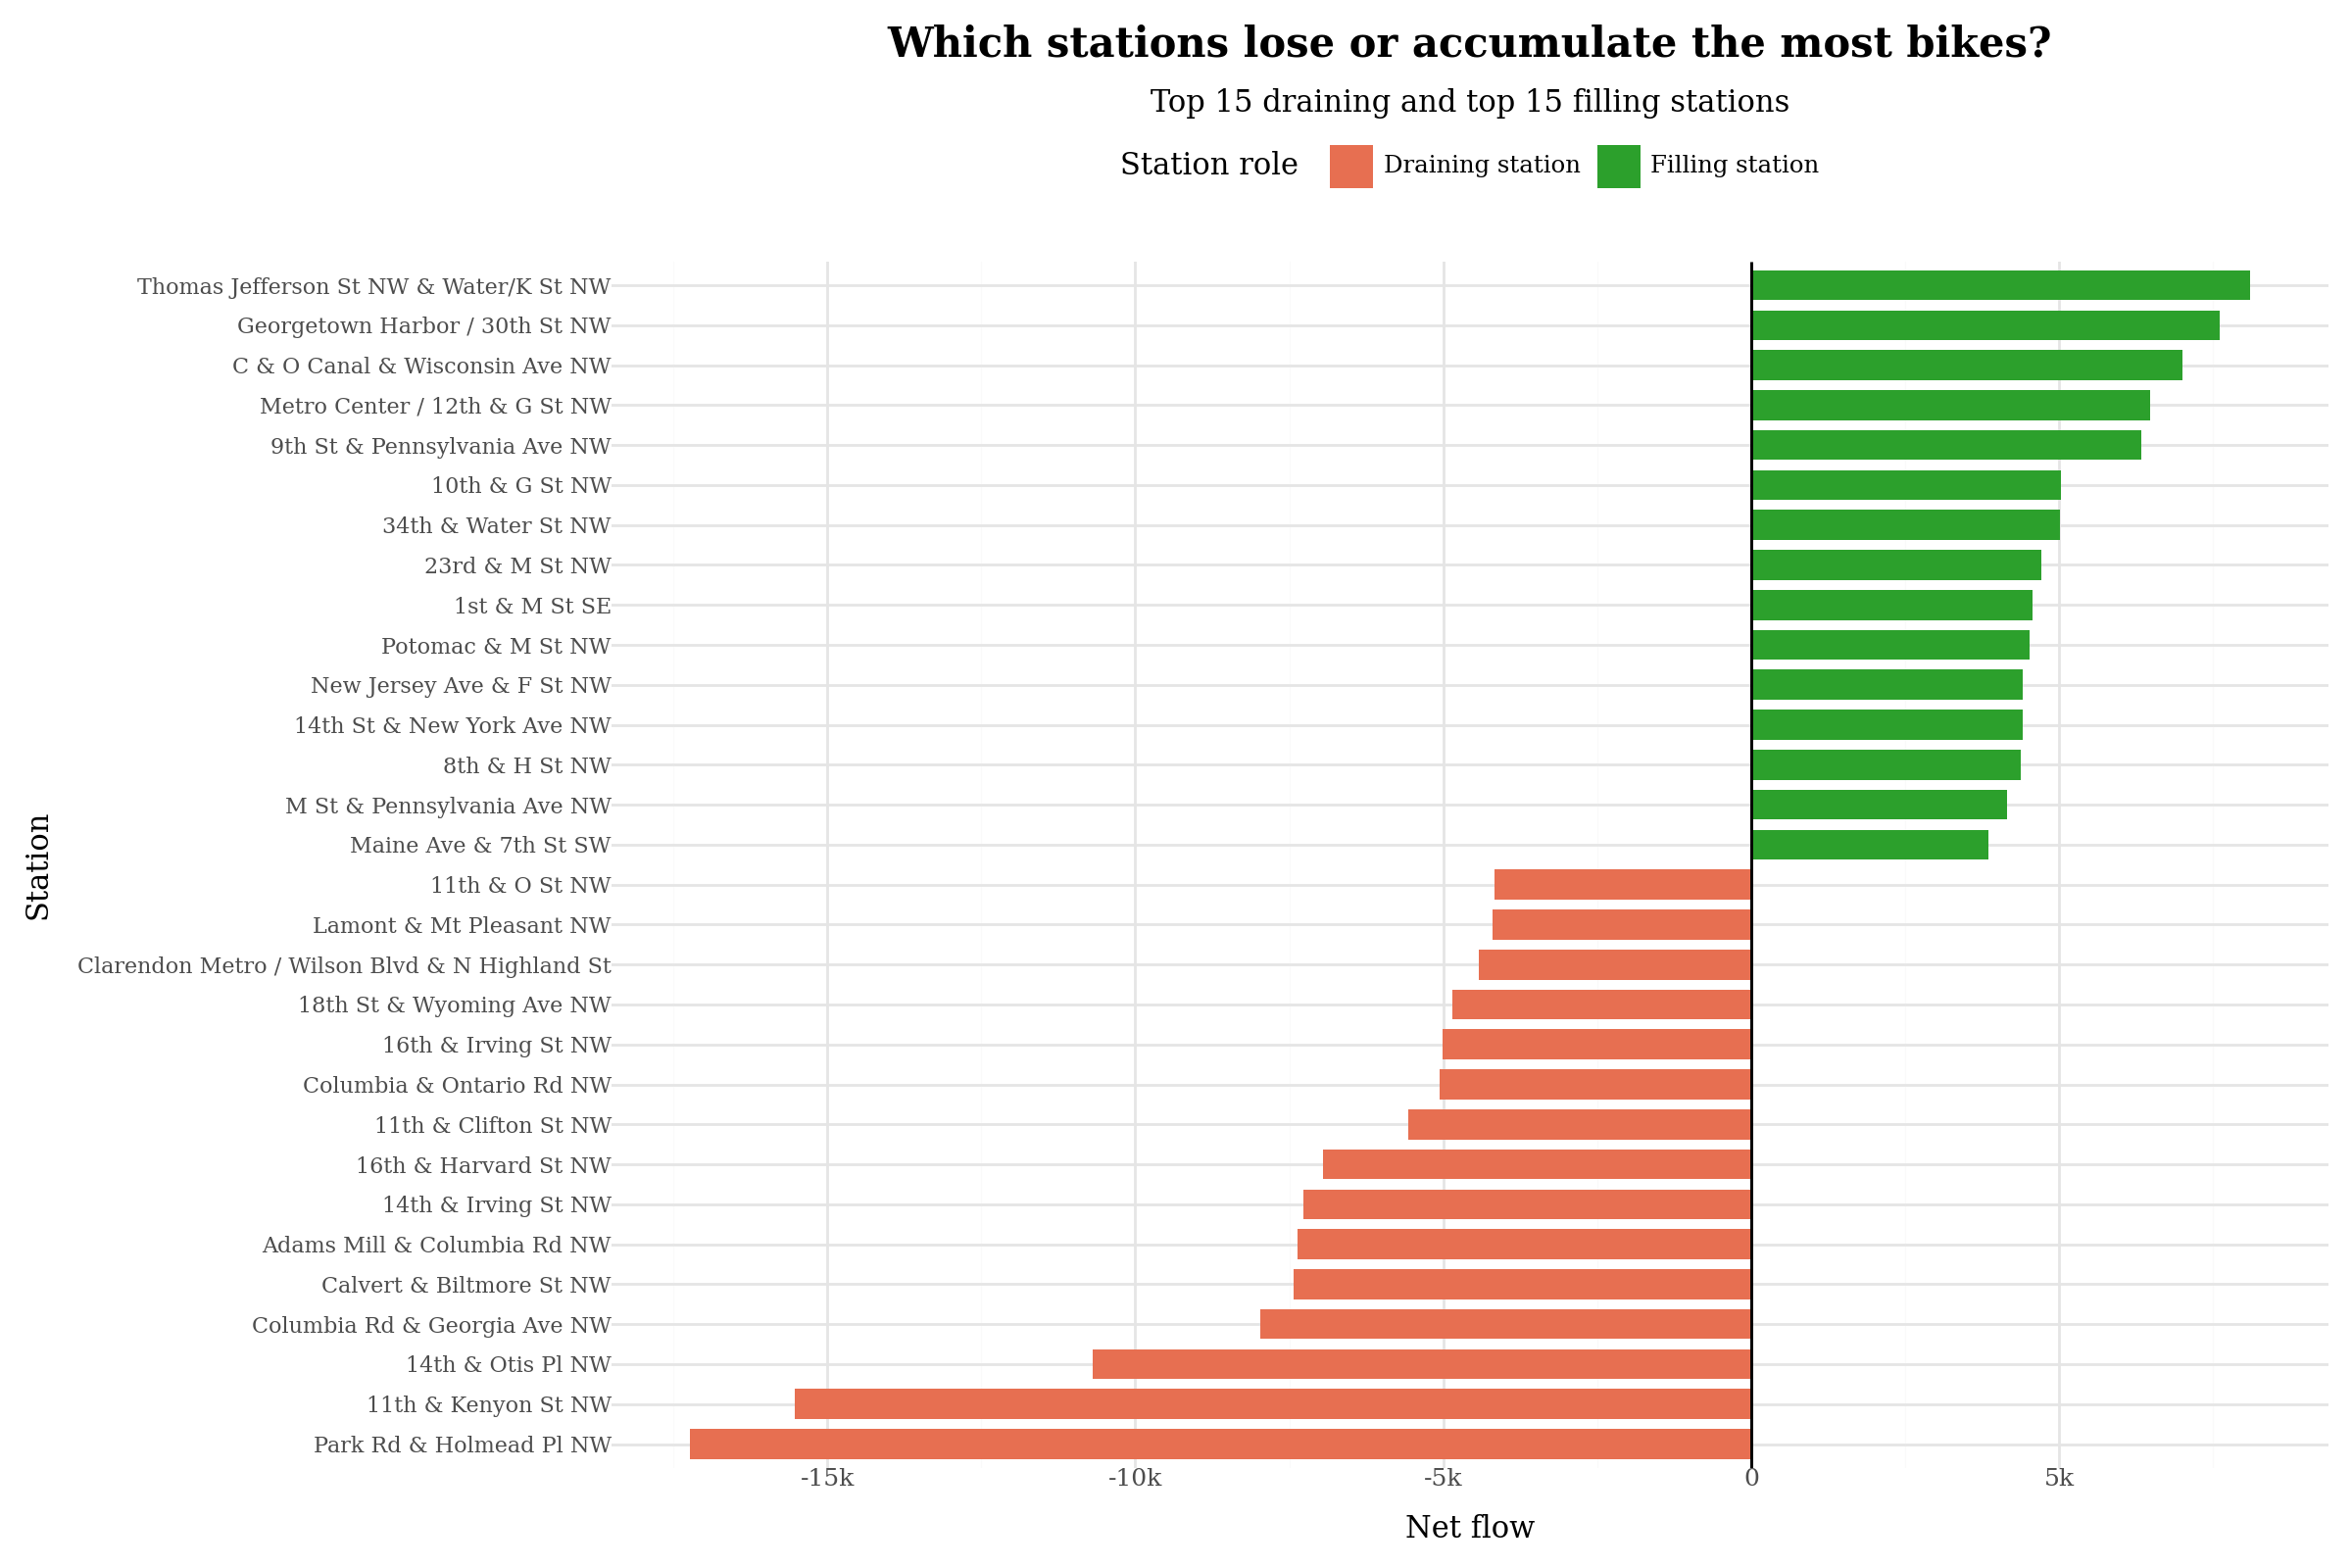

In [ ]:
# Diverging bar chart: station net flow

# Custom formatter for thousands
# This changes only the axis labels, not the actual net_flow values.
def k_format(values):
    labels = []

    for x in values:
        if x == 0:
            labels.append("0")
        else:
            labels.append(f"{int(x / 1000)}k")

    return labels


# Keep only stations with valid names
station_flow = (
    station_traffic
    .dropna(subset=["station_name"])
    .copy()
)

# Select the 15 strongest draining and 15 strongest filling stations
top_draining = station_flow.nsmallest(15, "net_flow").copy()
top_filling = station_flow.nlargest(15, "net_flow").copy()

net_flow_plot_df = (
    pd.concat([top_draining, top_filling], ignore_index=True)
    .sort_values("net_flow")
    .copy()
)

# Direction label for coloring
net_flow_plot_df["flow_type"] = np.where(
    net_flow_plot_df["net_flow"] >= 0,
    "Filling station",
    "Draining station"
)

# Make station names ordered by net flow
net_flow_plot_df["station_name"] = pd.Categorical(
    net_flow_plot_df["station_name"],
    categories=net_flow_plot_df["station_name"],
    ordered=True
)

# Plot
viz7_net_flow = (
    ggplot(
        net_flow_plot_df,
        aes(
            x="station_name",
            y="net_flow",
            fill="flow_type"
        )
    )
    + geom_col(width=0.75)
    + coord_flip()
    + geom_hline(
        yintercept=0,
        color="black",
        size=0.6
    )
    + scale_fill_manual(
        values={
            "Draining station": "#e76f51",
            "Filling station": PALETTE["ebike"]
        }
    )
    + scale_y_continuous(
        breaks=[-15000, -10000, -5000, 0, 5000, 10000],
        labels=k_format
    )
    + labs(
        title="Which stations lose or accumulate the most bikes?",
        subtitle="Top 15 draining and top 15 filling stations",
        x="Station",
        y="Net flow",
        fill="Station role"
    )
    + theme_minimal()
    + theme(
        text=element_text(family="DejaVu Serif"),

        figure_size=(12, 8),

        plot_title=element_text(
            size=15,
            weight="bold",
            family="DejaVu Serif"
        ),
        plot_subtitle=element_text(
            size=11,
            family="DejaVu Serif",
            ha="center"
        ),

        axis_title_x=element_text(
            size=11,
            family="DejaVu Serif"
        ),
        axis_title_y=element_text(
            size=11,
            family="DejaVu Serif"
        ),
        axis_text_x=element_text(
            size=9,
            family="DejaVu Serif"
        ),
        axis_text_y=element_text(
            size=8,
            family="DejaVu Serif"
        ),

        legend_title=element_text(
            family="DejaVu Serif"
        ),
        legend_text=element_text(
            family="DejaVu Serif"
        ),

        legend_position="top",
        plot_background=element_rect(fill="white", color="white"),
        panel_background=element_rect(fill="white", color="white"),
        legend_background=element_rect(fill="white", color="white")
    )
)

viz7_net_flow

In [ ]:
viz7_net_flow_white = (
    viz7_net_flow
    + theme(
        plot_background=element_rect(fill="white", color="white"),
        panel_background=element_rect(fill="white", color="white"),
        legend_background=element_rect(fill="white", color="white")
    )
)

viz7_net_flow_white.save(
    filename=f"{FIGURES}/viz7_station_net_flow.png",
    width=12,
    height=8,
    dpi=300,
    facecolor="white",
    transparent=False
)

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 12 x 8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/Team2_Bikeshare/05_deck/figures/viz7_station_net_flow.png


### **Duration filtering for visualization**

Trips longer than 120 minutes were excluded only for visualization purposes. The original duration distribution is highly right-skewed, with a median of about 10 minutes but a maximum close to 24 hours. If all extreme trips were kept in the violin plot, the y-axis would be dominated by very long rides and the main part of the distribution would be compressed near the bottom of the chart.

The 120-minute cutoff keeps the main usage pattern visible while removing only the most extreme long-duration trips. This allows the comparison between rider types and bike types to be interpreted more clearly.


In [ ]:
# Prepare data for violin plot

viz8_df = duration_distribution.copy()

# Keep only classic and electric bikes
viz8_df = viz8_df[
    viz8_df["rideable_type"].isin(["classic_bike", "electric_bike"])
].copy()

# Remove extreme long-duration trips for readability
viz8_df = viz8_df[
    viz8_df["duration_min"] <= 120
].copy()

# Cleaner labels
viz8_df["bike_type"] = viz8_df["rideable_type"].replace({
    "classic_bike": "Classic bike",
    "electric_bike": "E-bike"
})

viz8_df["rider_type"] = viz8_df["member_casual"].replace({
    "member": "Member",
    "casual": "Casual"
})

# Create explicit grouping column for plotnine
viz8_df["group_id"] = (
    viz8_df["bike_type"] + " - " + viz8_df["rider_type"]
)


### **Summary of duration behavior**

The summary statistics show that casual riders generally take longer trips than members. This is especially visible for classic bikes, where casual riders have a median duration of about 15.3 minutes, compared with about 9.0 minutes for members. This suggests that casual classic-bike trips are more leisure-oriented or exploratory.

For e-bikes, the difference between casual riders and members is smaller. Casual e-bike trips have a median duration of about 10.8 minutes, while member e-bike trips have a median duration of about 9.1 minutes. This suggests that e-bikes may be used more similarly across rider types, possibly because they support faster or more efficient trips.

In all groups, the mean duration is higher than the median duration. This confirms that trip durations are right-skewed: most trips are relatively short, but a smaller number of longer rides increases the average.


In [ ]:
# Summary statistics for interpretation

viz8_summary = (
    viz8_df
    .groupby(["bike_type", "rider_type"], as_index=False)
    .agg(
        trips=("duration_min", "size"),
        q1=("duration_min", lambda x: x.quantile(0.25)),
        median_duration=("duration_min", "median"),
        q3=("duration_min", lambda x: x.quantile(0.75)),
        mean_duration=("duration_min", "mean")
    )
)

# Calculate interquartile range
viz8_summary["iqr"] = viz8_summary["q3"] - viz8_summary["q1"]

# Columns to round
numeric_cols = [
    "q1",
    "median_duration",
    "q3",
    "iqr",
    "mean_duration"
]

# Round numeric duration values
viz8_summary[numeric_cols] = viz8_summary[numeric_cols].round(2)

# Display rounded table
display(
    viz8_summary.style.format({
        "trips": "{:,}",
        "q1": "{:.2f}",
        "median_duration": "{:.2f}",
        "q3": "{:.2f}",
        "iqr": "{:.2f}",
        "mean_duration": "{:.2f}"
    })
)

,bike_type,rider_type,trips,q1,median_duration,q3,mean_duration,iqr
0,Classic bike,Casual,"95,865",8.88,15.28,28.36,22.58,19.48
1,Classic bike,Member,"181,542",5.35,8.95,14.80,11.86,9.45
2,E-bike,Casual,"77,383",6.60,10.83,17.96,15.36,11.36
3,E-bike,Member,"154,551",5.28,9.06,14.98,12.01,9.69


### Interpretation

This violin-boxplot compares trip duration between classic bikes and e-bikes, separately for casual riders and members.

The main pattern is that **rider type is a stronger driver of trip duration than bike type**. Members have shorter and more concentrated trip durations, with median trips around 9 minutes for both classic bikes and e-bikes. This suggests that members mostly use the system for short, practical trips, such as commuting or connecting to public transport.

Casual riders have longer and more variable trips. This is especially visible for classic bikes, where the median duration is about 15.3 minutes and the mean duration is about 22.6 minutes. This pattern suggests more leisure-oriented or exploratory use.

For e-bikes, the difference between casual riders and members is smaller. Casual e-bike trips have a median duration of about 10.8 minutes, while member e-bike trips have a median duration of about 9.1 minutes. This suggests that e-bikes may support more time-efficient trips across both rider groups.

The diamond markers represent the mean and are above the median lines in all groups. This confirms that trip durations are right-skewed: most rides are short, but a smaller number of longer rides increases the average duration.

Trips longer than 120 minutes were excluded only for visualization readability, so that the main duration patterns would not be compressed by extreme long-duration trips.

The violin shapes show how most trips are short, but the long upper tails indicate that some trips last must longer. The boxplots show that members have shorter and more concetrated trip durations, while casual riders have longer and more variable trips. The median confirms that typical casual trips are longer, especially for classic bikes. The mean is higher than the median, which shows that trip durations are right-skewed, most rides are short, but a smaller number of long rides increases the average.

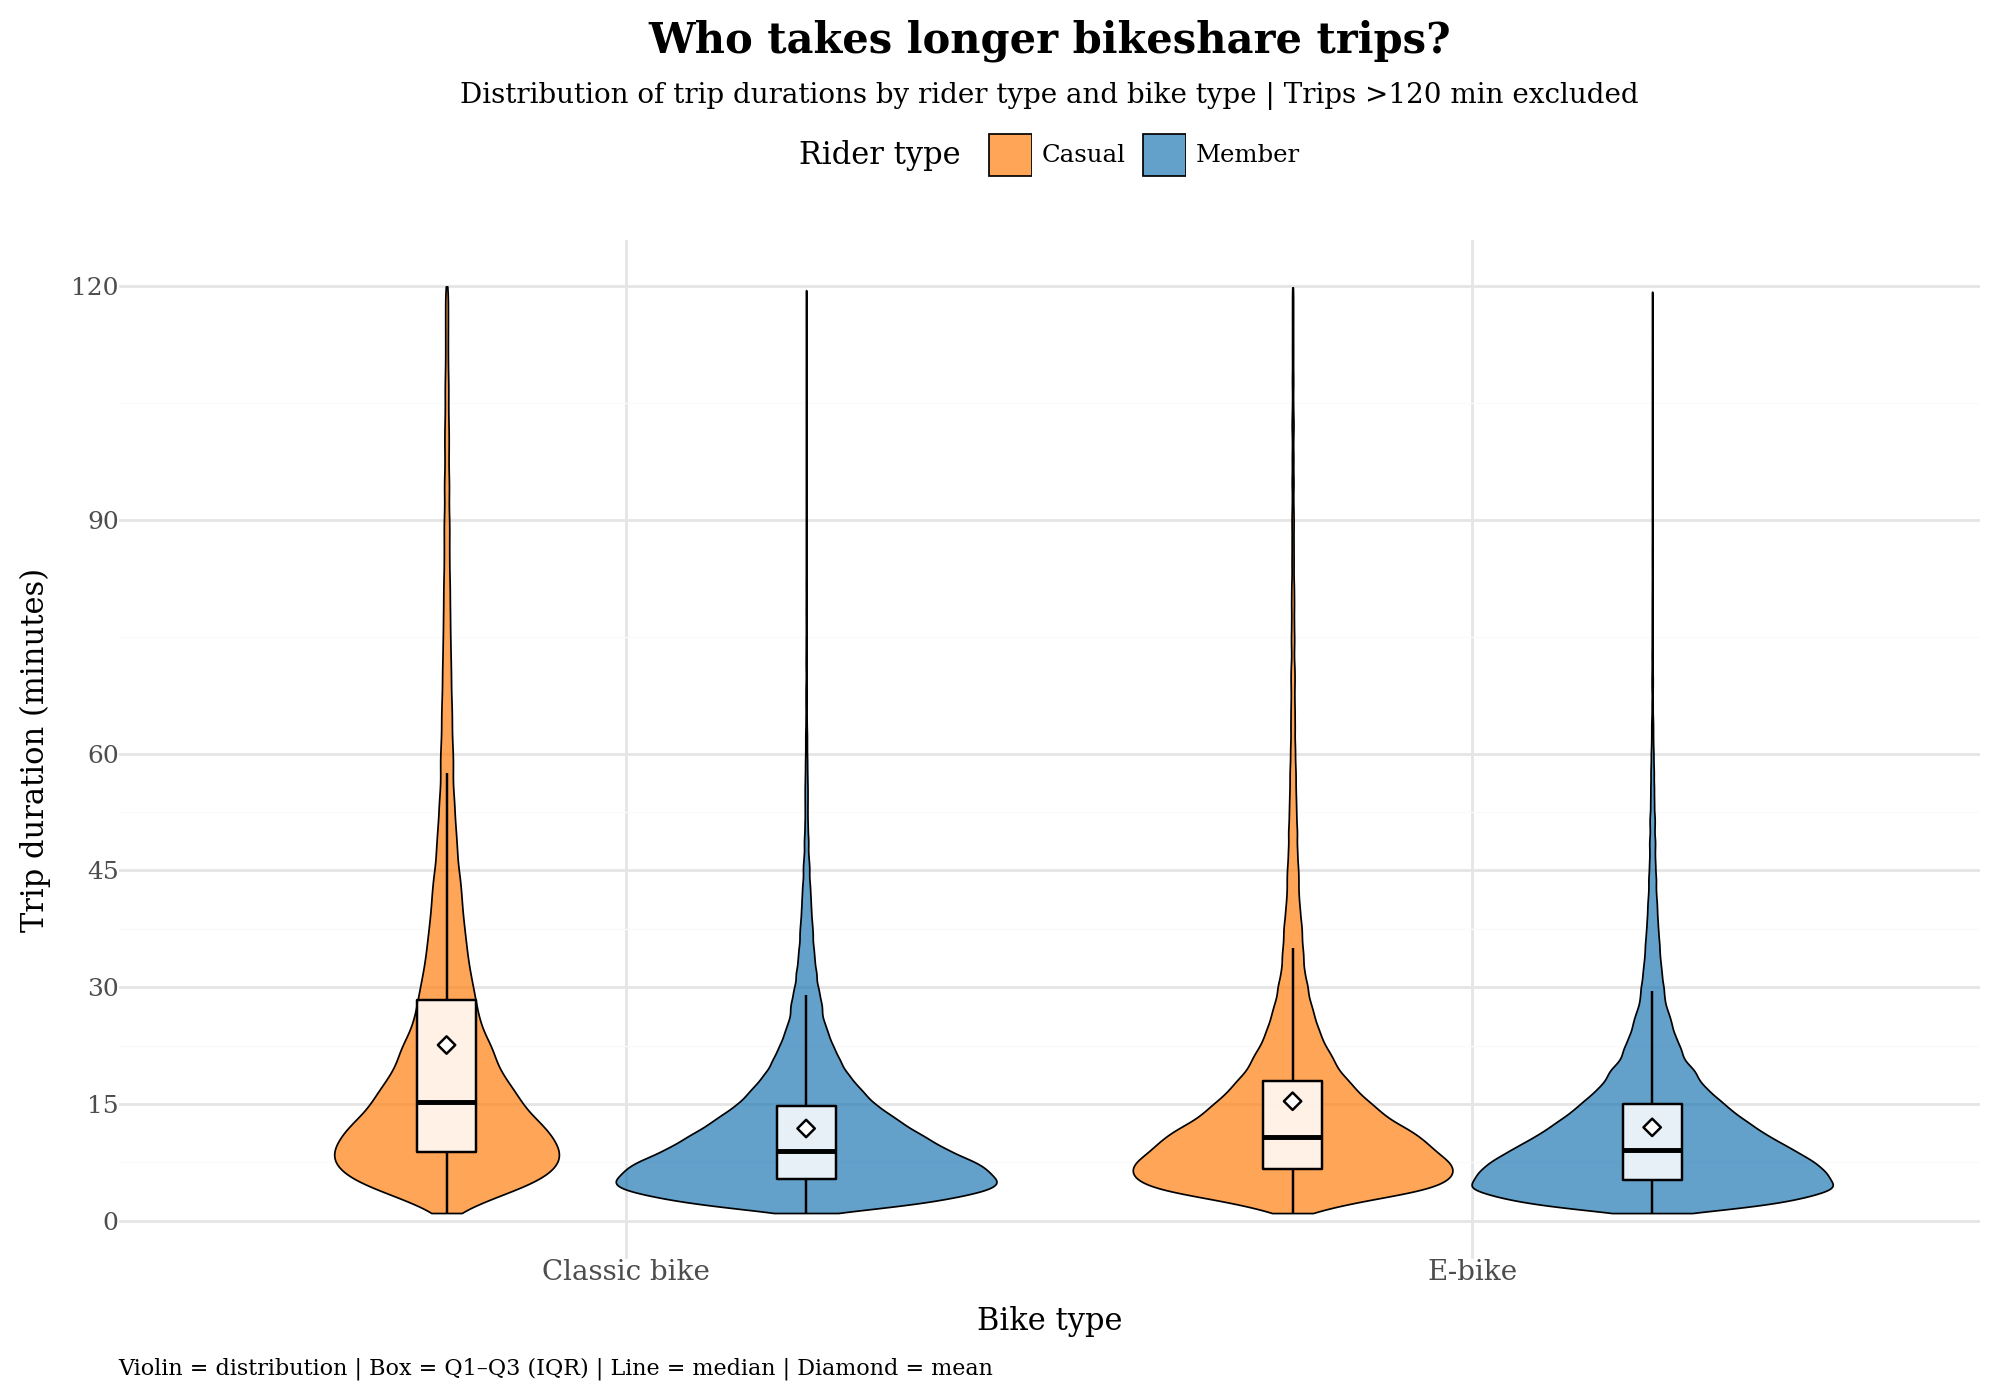

In [ ]:
from plotnine.positions import position_dodge


# Violin + boxplot: bike type behaviour

dodge = position_dodge(width=0.85)

viz8_violin = (
    ggplot(
        viz8_df,
        aes(
            x="bike_type",
            y="duration_min",
            fill="rider_type",
            group="group_id"
        )
    )

    # Violin distribution
    + geom_violin(
        position=dodge,
        alpha=0.70,
        width=0.9,
        trim=True,
        color="black",
        size=0.35
    )

    # Boxplot inside violin: Q1, median, Q3, IQR
    + geom_boxplot(
        position=dodge,
        width=0.14,
        fill="white",
        color="black",
        outlier_alpha=0,
        alpha=0.85,
        show_legend=False
    )

    # Mean marker
    + stat_summary(
        fun_y=np.mean,
        geom="point",
        position=dodge,
        shape="D",
        size=2.0,
        color="black",
        fill="white",
        show_legend=False
    )

    + scale_fill_manual(
        values={
            "Member": PALETTE["member"],
            "Casual": PALETTE["casual"]
        }
    )

    + scale_y_continuous(
        breaks=[0, 15, 30, 45, 60, 90, 120]
    )

    + labs(
        title="Who takes longer bikeshare trips?",
        subtitle="Distribution of trip durations by rider type and bike type | Trips >120 min excluded",
        caption="Violin = distribution | Box = Q1–Q3 (IQR) | Line = median | Diamond = mean",
        x="Bike type",
        y="Trip duration (minutes)",
        fill="Rider type"
    )

    + theme_minimal()

    + theme(
        text=element_text(family="DejaVu Serif"),

        figure_size=(10, 7),

        plot_title=element_text(
            size=15,
            weight="bold",
            family="DejaVu Serif",
            ha="center"
        ),
        plot_subtitle=element_text(
            size=10,
            family="DejaVu Serif",
            ha="center"
        ),
        plot_caption=element_text(
            size=8,
            ha="left",
            family="DejaVu Serif"
        ),

        axis_title_x=element_text(
            size=11,
            family="DejaVu Serif"
        ),
        axis_title_y=element_text(
            size=11,
            family="DejaVu Serif"
        ),
        axis_text_x=element_text(
            size=10,
            family="DejaVu Serif"
        ),
        axis_text_y=element_text(
            size=9,
            family="DejaVu Serif"
        ),

        legend_title=element_text(
            family="DejaVu Serif"
        ),
        legend_text=element_text(
            family="DejaVu Serif"
        ),

        legend_position="top",
        plot_background=element_rect(fill="white", color="white"),
        panel_background=element_rect(fill="white", color="white"),
        legend_background=element_rect(fill="white", color="white")
    )
)

viz8_violin

In [ ]:
viz8_violin.save(
    filename=f"{FIGURES}/viz8_bike_type_violin.png",
    width=10,
    height=7,
    dpi=300,
    facecolor="white",
    transparent=False
)

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 7 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/Team2_Bikeshare/05_deck/figures/viz8_bike_type_violin.png


### Top station traffic table

This table lists the top 15 busiest Capital Bikeshare stations during 2023–2024. For each station, `starts` shows how many trips began there, `ends` shows how many trips finished there, and `total_trips` is the sum of starts and ends.

The table confirms that the busiest stations have high activity in both directions, meaning they are not only popular starting points but also important trip destinations. `Columbus Circle / Union Station` is the busiest station overall, with more than 200,000 total trips.

Total station traffics calculated as:

**total trips = trip starts + trip ends**

A lollipop chart is used instead of a standard bar chart to keep the ranking clean and readable, while still showing the relative difference between the busiest stations.

In [ ]:
# Prepare top-N busiest stations

N = 15

busiest_stations = (
    station_traffic
    .dropna(subset=["station_name"])
    .copy()
)

# Convert trips count columns to integers
count_cols = ["starts", "ends", "total_trips"]

busiest_stations[count_cols] = (
    busiest_stations[count_cols]
    .round()
    .astype(int)
)

busiest_stations = (
    busiest_stations
    .nlargest(N, "total_trips")
    .sort_values("total_trips")
    .copy()
)

# Ordered station labels for plotting
busiest_stations["station_name"] = pd.Categorical(
    busiest_stations["station_name"],
    categories=busiest_stations["station_name"],
    ordered=True
)

# Helper columns
busiest_stations["zero"] = 0
busiest_stations["trip_label"] = busiest_stations["total_trips"].map(lambda x: f"{x:,.0f}")

busiest_stations_table = (
    busiest_stations
    .sort_values("total_trips", ascending=False)
    [["station_name", "starts", "ends", "total_trips"]]
)

display(busiest_stations_table)

,station_name,starts,ends,total_trips
392,Columbus Circle / Union Station,100801,101153,201954
167,New Hampshire Ave & T St NW,90824,89125,179949
139,15th & P St NW,79857,80059,159916
370,5th & K St NW,73240,74619,147859
373,1st & M St NE,72888,73400,146288
101,14th & V St NW,72792,69883,142675
138,Massachusetts Ave & Dupont Circle NW,67430,69820,137250
196,Lincoln Memorial,64204,63906,128110
383,Eastern Market Metro / Pennsylvania Ave & 8th ...,64024,64046,128070
396,3rd & M St NE,63306,64449,127755


### **Interpretation**

This lollipop chart ranks the 15 busiest Capital Bikeshare stations during 2023–2024, based on total station traffic. Total traffic is defined as the sum of trip starts and trip ends.

The chart highlights the main activity hubs of the bikeshare network. Stations such as **Columbus Circle / Union Station**, **New Hampshire Ave & T St NW**, and **15th & P St NW** attract the highest volume of trips, suggesting strong demand in central, highly connected, and high-activity urban locations.

This visualization complements the station net-flow chart. A station may be very busy because it handles many trips overall, even if it is relatively balanced in terms of starts and ends. Therefore, combining total traffic and net flow provides a more complete picture of how the system is used operationally.

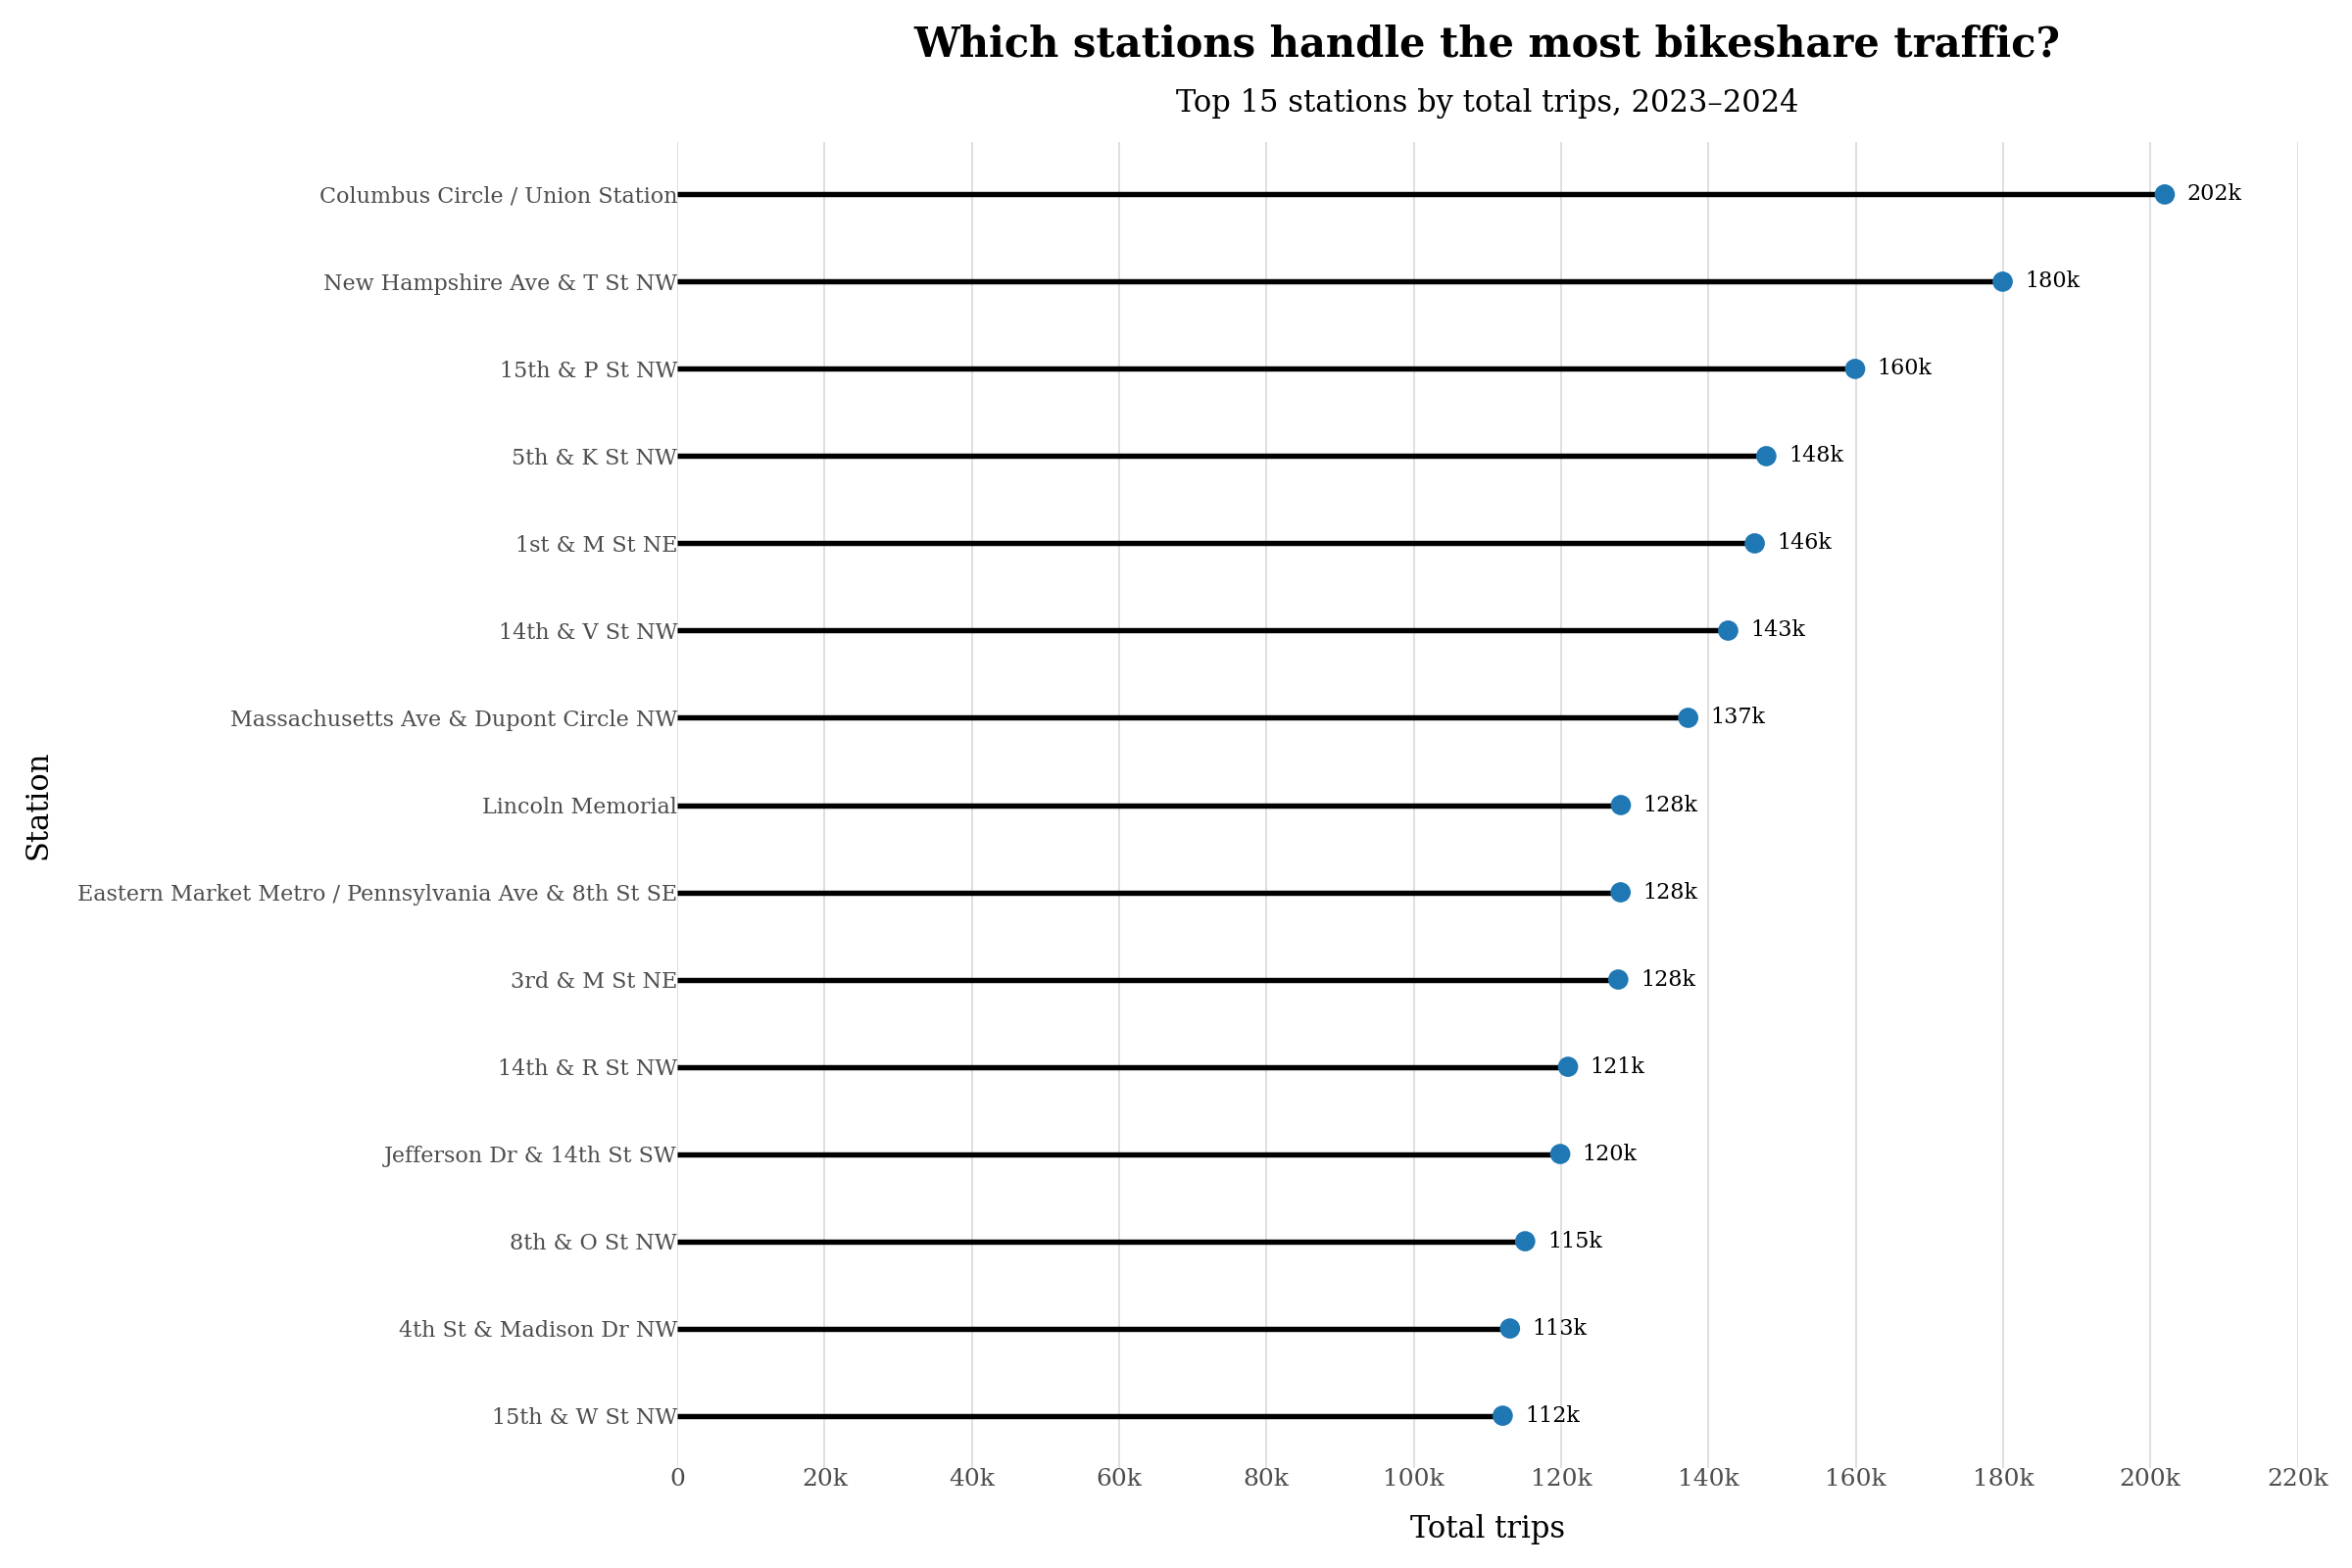

In [ ]:
# Lollipop chart: top busiest stations

# Custom formatter for x-axis labels in thousands
def k_format(values):
    labels = []

    for x in values:
        if x == 0:
            labels.append("0")
        else:
            labels.append(f"{int(x / 1000)}k")

    return labels


# Keep only stations with valid names
station_busy = (
    station_traffic
    .dropna(subset=["station_name"])
    .copy()
)

# Make count columns integers for consistency
count_cols = ["starts", "ends", "total_trips"]
station_busy[count_cols] = (
    station_busy[count_cols]
    .round()
    .astype(int)
)

# Top 15 busiest stations by total trips
top_busy_stations = (
    station_busy
    .nlargest(15, "total_trips")
    .sort_values("total_trips", ascending=True)
    .copy()
)

# Order station names for plotting
top_busy_stations["station_name"] = pd.Categorical(
    top_busy_stations["station_name"],
    categories=top_busy_stations["station_name"],
    ordered=True
)

# Rounded labels in thousands
top_busy_stations["trip_label"] = top_busy_stations["total_trips"].map(
    lambda x: f"{round(x / 1000):.0f}k"
)

# Plot
viz9_lollipop = (
    ggplot(top_busy_stations)

    # Lollipop stems
    + geom_segment(
        aes(
            x=0,
            xend="total_trips",
            y="station_name",
            yend="station_name"
        ),
        color="black",
        size=1.1
    )

    # Lollipop heads
    + geom_point(
        aes(
            x="total_trips",
            y="station_name"
        ),
        color=PALETTE["member"],
        size=3.2
    )

    # Value labels
    + geom_text(
        aes(
            x="total_trips",
            y="station_name",
            label="trip_label"
        ),
        nudge_x=3000,
        size=8,
        ha="left",
        family="DejaVu Serif"
    )

    + scale_x_continuous(
        limits=[0, 220000],
        breaks=list(range(0, 220001, 20000)),
        labels=k_format,
        expand=(0, 0)
    )

    + labs(
        title="Which stations handle the most bikeshare traffic?",
        subtitle="Top 15 stations by total trips, 2023–2024",
        x="Total trips",
        y="Station"
    )

    + theme_minimal()

    + theme(
        text=element_text(family="DejaVu Serif"),

        figure_size=(12, 8),

        plot_title=element_text(
            size=15,
            weight="bold",
            family="DejaVu Serif"
        ),
        plot_subtitle=element_text(
            size=11,
            family="DejaVu Serif",
            ha="center"
        ),

        axis_title_x=element_text(
            size=11,
            family="DejaVu Serif"
        ),
        axis_title_y=element_text(
            size=11,
            family="DejaVu Serif"
        ),
        axis_text_x=element_text(
            size=9,
            family="DejaVu Serif"
        ),
        axis_text_y=element_text(
            size=8,
            family="DejaVu Serif"
        ),

        # Keep vertical grid lines
        panel_grid_major_x=element_line(color="#d9d9d9", size=0.6),
        panel_grid_minor_x=element_blank(),

        # Remove horizontal grid lines
        panel_grid_major_y=element_blank(),
        panel_grid_minor_y=element_blank(),

        plot_background=element_rect(fill="white", color="white"),
        panel_background=element_rect(fill="white", color="white")
    )
)

viz9_lollipop

In [ ]:
viz9_lollipop.save(
    filename=f"{FIGURES}/viz9_top_busiest_stations_lollipop.png",
    width=12,
    height=8,
    dpi=300,
    facecolor="white",
    transparent=False
)

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 12 x 8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/Team2_Bikeshare/05_deck/figures/viz9_top_busiest_stations_lollipop.png
